In [ ]:
import sys
sys.path.append('C:/Users/ryansenne/PycharmProjects/dCA1_Paper')

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import iqr
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Post hoc analysis of hierarchical bayesian model of Figure 2

In [2]:
df = pd.read_csv(r"C:\Users\ryansenne\Desktop\Dill\astrocyte_shot_Gaussian_noise3_all.csv")
df

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal
0,1,0.0,0.0,2.6,0.5,0.5,0.512348,2.675,2.6,2.9,2.0,3.2,1,F3.
1,10,0.0,0.0,2.3,0.8,0.6,0.493288,2.350,2.3,2.3,1.8,3.0,10,F3.
2,100,0.0,0.0,13.0,8.1,0.8,2.459505,5.325,7.1,4.2,7.6,2.4,100,F3.
3,1000,0.1,0.0,3.2,0.8,0.3,0.287228,3.175,3.1,3.0,3.0,3.6,1000,F9.
4,1001,0.1,0.0,3.7,1.3,0.2,0.330404,3.625,3.2,3.7,3.6,4.0,1001,F9.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2650,995,0.1,0.0,4.1,0.9,1.5,1.797220,3.850,2.4,2.4,4.5,6.1,995,F9.
2651,996,0.1,0.0,3.2,1.1,0.2,0.000000,3.200,3.2,3.2,3.2,3.2,996,F9.
2652,997,0.1,0.0,3.2,0.9,0.5,0.408248,3.200,3.3,2.6,3.4,3.5,997,F9.
2653,998,0.2,0.0,5.6,2.2,0.2,0.320156,5.675,5.8,5.2,5.9,5.8,998,F9.


## Density Plot of Peak Times

## Linear Mixed Effects Model

In [3]:
# RI only (random intercept)
res_ri_ml = smf.mixedlm("pred_sigma ~ pred_mu", data=df, groups=df["animal"]).fit()

# RI+RS
m_rs = smf.mixedlm("pred_sigma ~ pred_mu", data=df, groups=df["animal"], re_formula="~pred_mu")
res_rs_ml = m_rs.fit(reml=False, method="lbfgs")

# # Likelihood ratio test (nested models)
lr_stat = 2 * (res_rs_ml.llf - res_ri_ml.llf)
df_diff = res_rs_ml.df_modelwc - res_ri_ml.df_modelwc  # parameter count difference
from scipy.stats import chi2
pval = chi2.sf(lr_stat, df_diff)
print(f"LR stat = {lr_stat:.3f}, df = {df_diff}, p = {pval:.4g}")


c:\Users\ryansenne\anaconda3\envs\dCA1_Paper\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ryansenne\anaconda3\envs\dCA1_Paper\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


LR stat = 444.749, df = 2, p = 2.654e-97


In [4]:
res_ri_ml.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
========================================================
Model:            MixedLM Dependent Variable: pred_sigma
No. Observations: 2655    Method:             REML      
No. Groups:       13      Scale:              4.3092    
Min. group size:  98      Log-Likelihood:     -5720.2044
Max. group size:  309     Converged:          Yes       
Mean group size:  204.2                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -0.401    0.094 -4.288 0.000 -0.585 -0.218
pred_mu        0.348    0.007 49.137 0.000  0.334  0.361
Group Var      0.068    0.016                           
========================================================

"""

In [5]:
res_rs_ml.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM   Dependent Variable:   pred_sigma
No. Observations:   2655      Method:               ML        
No. Groups:         13        Scale:                3.6152    
Min. group size:    98        Log-Likelihood:       -5497.8297
Max. group size:    309       Converged:            Yes       
Mean group size:    204.2                                     
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.304    0.206 -1.474 0.140 -0.707  0.100
pred_mu              0.323    0.042  7.707 0.000  0.241  0.405
Group Var            0.484    0.110                           
Group x pred_mu Cov -0.097    0.022                           
pred_mu Var          0.020    0.004                           
==============================================================

"""

C:\Users\ryansenne\AppData\Local\Temp\ipykernel_29260\2987064579.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("tab20")


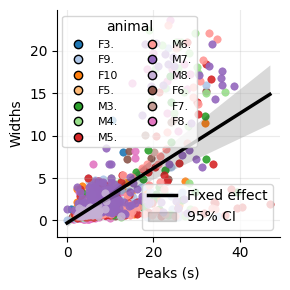

In [34]:
# --- Choose which fitted model to visualize ---
# model = res_ri_ml
model = res_rs_ml

# === 0) Helpers to make naming robust ===
fe = model.fe_params
fe_names = list(fe.index)

# Fixed-effect names
intercept_name = "Intercept" if "Intercept" in fe_names else ("const" if "const" in fe_names else None)
slope_name = "pred_mu"  # as used in your formula

if intercept_name is None:
    raise ValueError("Could not find Intercept/const in fixed effects.")

beta0 = float(fe[intercept_name])
beta1 = float(fe[slope_name])

# Covariance of FIXED effects only (for CI around the black line)
cov_all = model.cov_params()
cov_fe = cov_all.loc[fe.index, fe.index]
col_order = [intercept_name, slope_name]
cov_mat = cov_fe.loc[col_order, col_order].values

# === 1) Scatter each animal in its own color ===
fig, ax = plt.subplots(figsize=(3, 3))

animals = list(df["animal"].unique())
cmap = get_cmap("tab20")
color_map = {a: cmap(i % 20) for i, a in enumerate(animals)}

for a, g in df.groupby("animal"):
    ax.scatter(g["pred_mu"], g["pred_sigma"], label=str(a), alpha=0.9, s=28, color=color_map[a], linewidths=0.5)

ax.set_xlabel("Peaks (s)")
ax.set_ylabel("Widths")

# === 2) Population (fixed-effect) line + 95% CI ===
xgrid = np.linspace(df["pred_mu"].min(), df["pred_mu"].max(), 200)
X = np.column_stack([np.ones_like(xgrid), xgrid])

beta_vec = np.array([beta0, beta1])
yhat = X @ beta_vec
var = np.einsum("ij,jk,ik->i", X, cov_mat, X)  # diag(X Σ Xᵀ)
se = np.sqrt(var)
z = 1.96
lo, hi = yhat - z * se, yhat + z * se

ax.plot(xgrid, yhat, color="black", lw=2.5, label="Fixed effect")
ax.fill_between(xgrid, lo, hi, color="black", alpha=0.15, linewidth=0, label="95% CI")

# === 3) Subject-specific lines (fixed + random effects) ===
# Each group's random effects are in model.random_effects[group]
# Names usually include 'Intercept' (or sometimes only one unnamed column for RI-only) and 'pred_mu' for RS.
re_dict = model.random_effects  # {group: pandas Series or array-like}

def extract_group_effects(re_series):
    """Return (u0, u1) for intercept and slope random effects for a group.
       Robust to RI-only models and naming differences.
    """
    # Convert to dict-like with names if needed
    if hasattr(re_series, "index"):
        names = list(re_series.index)
        # Intercept
        if "Intercept" in names:
            u0 = float(re_series["Intercept"])
        elif "const" in names:
            u0 = float(re_series["const"])
        elif len(re_series) == 1:
            # RI-only often returns a single entry
            u0 = float(re_series.iloc[0])
        else:
            # Fallback
            u0 = 0.0
        # Slope
        u1 = float(re_series["pred_mu"]) if "pred_mu" in names else 0.0
    else:
        # If array-like without names: assume RI-only
        arr = np.asarray(re_series).ravel()
        u0 = float(arr[0]) if arr.size >= 1 else 0.0
        u1 = float(arr[1]) if arr.size >= 2 else 0.0
    return u0, u1

# # Draw each group's line in its color (light, thin) across its x-range to reduce clutter
# for a, g in df.groupby("animal"):
#     u0, u1 = extract_group_effects(re_dict[a])
#     b0_g = beta0 + u0
#     b1_g = beta1 + u1

#     # Optional: restrict line to that animal's observed x-range
#     xg = np.linspace(g["pred_mu"].min(), g["pred_mu"].max(), 50)
#     yg = b0_g + b1_g * xg

#     ax.plot(xg, yg, color=color_map[a], lw=1.8, alpha=0.8)

# === 4) Styling ===
# Put animal legend in one place; add custom handles for FE line + CI
animal_handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=color_map[a], label=str(a), markersize=6)
                  for a in animals]

fe_handles = [
    Line2D([0], [0], color='black', lw=2.5, label='Fixed effect'),
    Patch(facecolor='black', alpha=0.15, label='95% CI')
]

first_legend = ax.legend(handles=animal_handles, title="animal", fontsize=8, ncol=2, loc="upper left", frameon=True)
ax.add_artist(first_legend)
ax.legend(handles=fe_handles, loc="lower right", frameon=True)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.savefig("lmem.svg")


# Make histogram of all peak times

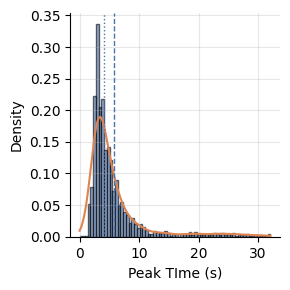

In [26]:
x = df["pred_mu"].dropna().to_numpy()

# Focus on the bulk trim extreme tail for visualization
p99 = np.percentile(x, 99)
x_view = x[x <= p99]

# Freedman–Diaconis bin width
bw = 2 * iqr(x_view) / (len(x_view) ** (1/3))
nbins = int(np.ceil((x_view.max() - x_view.min()) / bw)) if bw > 0 else "auto"

fig, ax = plt.subplots(figsize=(3,3))
ax.hist(x_view, bins=nbins, density=True, alpha=0.6, edgecolor="black")

# KDE (matplotlib only)
kde = gaussian_kde(x_view)  # Scott’s rule by default
xs = np.linspace(x_view.min(), x_view.max(), 512)
ax.plot(xs, kde(xs))

# Summary lines
ax.axvline(x_view.mean(), linestyle="--", linewidth=1)
ax.axvline(np.median(x_view), linestyle=":", linewidth=1)

ax.set_xlabel("Peak TIme (s)")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig("kde_plot.svg")